In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import rasterio
import rioxarray as rxr

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import string

In [2]:
# Local input and output paths
working_dir = Path.cwd().resolve()
repository_root = next(
    parent
    for parent in (working_dir, *working_dir.parents)
    if (parent / "07_postprocess_data" / "local" / "species_richness_from_SDM_projections" / "data" / "results_mean_ETresid").is_dir()
)
base_path = (
    repository_root
    / "07_postprocess_data"
    / "local"
    / "species_richness_from_SDM_projections"
    / "data"
    / "results_mean_ETresid"
)
plot_dir = repository_root / "08_figures" / "main_figures" / "figure_2" / "output"
plot_dir.mkdir(parents=True, exist_ok=True)

# Shared Amazon Basin mask for the pixel-aligned map boundaries.
amazon_mask_path = repository_root / "01_climate_data" / "01_c_NorESM2" / "amazon_mask" / "amazon_mask.tif"
with rasterio.open(amazon_mask_path) as src:
    amazon_mask_values = src.read(1)
    amazon_mask_transform = src.transform

# Define SSP.
ssp = "ssp245"

# Scenarios and time periods.
scenarios = [
    {"name": f"{ssp}_notip_no_deforestation", "label": "no tip", "type": "notip"},
    {"name": f"{ssp}_tip_no_deforestation", "label": "tip + no defor", "type": "tip_no_defor"},
    {"name": f"{ssp}_tip_deforestation", "label": "tip + defor", "type": "tip_defor"},
]
time_periods = ["2030_2044", "2050_2069", "2080_2099"]

def sr_file(kind, scenario, period):
    """Return a production all-species mean richness raster created in step 07."""
    return base_path / scenario / period / f"{kind}_species_richness_mean_all_species.tif"

C:\Users\Clemens\AppData\Local\Temp\ipykernel_18884\747847520.py:22: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  amazon_mask_values = src.read(1)


In [3]:
# Check that the production all-species mean rasters are available.
# These are calculated from the matched per-MC all-taxon maps in step 07;
# Figure 2 does not sum taxon-specific rasters itself.
rasters = {"historic": {}, "future": {}, "delta": {}}

for sc in scenarios:
    scen_name = sc["name"]
    for tp in time_periods:
        key = f"{scen_name}_{tp}"
        paths = {
            "historic": sr_file("historic", scen_name, tp),
            "future": sr_file("future", scen_name, tp),
            "delta": sr_file("delta", scen_name, tp),
        }
        missing = [str(path) for path in paths.values() if not path.is_file()]
        if missing:
            raise FileNotFoundError("Missing production all-species richness raster(s):\n" + "\n".join(missing))
        for kind, path in paths.items():
            rasters[kind][key] = path

print(f"Validated {len(scenarios) * len(time_periods) * 3} all-species mean richness rasters.")

Validated 27 all-species mean richness rasters.


In [4]:
# Compute global min/max across ALL-SPECIES rasters

def global_min_max(file_list, cast_int=False):
    vals = []

    for fpath in file_list:
        if not os.path.exists(fpath):
            continue

        with rasterio.open(fpath) as src:
            arr = src.read(1, masked=True)
            vals.append(arr.min())
            vals.append(arr.max())

    vmin = np.nanmin(vals)
    vmax = np.nanmax(vals)

    if cast_int:
        vmin = int(vmin)
        vmax = int(vmax)

    return float(vmin), float(vmax)


# Collect all-species raster paths

hist_files = []
fut_files = []
delta_files = []

for sc in scenarios:
    scen_name = sc["name"]

    for tp in time_periods:
        base = os.path.join(base_path, scen_name, tp)

        hist_files.append(
            os.path.join(base, "historic_species_richness_mean_all_species.tif")
        )
        fut_files.append(
            os.path.join(base, "future_species_richness_mean_all_species.tif")
        )
        delta_files.append(
            os.path.join(base, "delta_species_richness_mean_all_species.tif")
        )

# Compute global min/max
hist_min, hist_max = global_min_max(hist_files)
print("Global historic min/max:", hist_min, hist_max)

fut_min, fut_max = global_min_max(fut_files)
print("Global future min/max:", fut_min, fut_max)

delta_min, delta_max = global_min_max(delta_files, cast_int=True)
print("Global delta min/max:", delta_min, delta_max)


Global historic min/max: 78.69999694824219 1104.280029296875
Global future min/max: 60.900001525878906 1088.43994140625
Global delta min/max: -564.0 173.0


In [5]:
data = {}

# Bounding box
minx, miny, maxx, maxy = -80, -20, -50, 5

for sc in scenarios:
    scen_name = sc["name"]
    data[scen_name] = {}

    for tp in time_periods:
        base = os.path.join(base_path, scen_name, tp)

        f_hist  = os.path.join(base, "historic_species_richness_mean_all_species.tif")
        f_fut   = os.path.join(base, "future_species_richness_mean_all_species.tif")
        f_delta = os.path.join(base, "delta_species_richness_mean_all_species.tif")

        # Load
        hist_da  = rxr.open_rasterio(f_hist).squeeze()
        fut_da   = rxr.open_rasterio(f_fut).squeeze()
        delta_da = rxr.open_rasterio(f_delta).squeeze()

        hist_da = hist_da 
        fut_da  = fut_da 
        
        # Clip to bounding box
        hist_da  = hist_da.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
        fut_da   = fut_da.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
        delta_da = delta_da.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)

        # Store cleanly
        data[scen_name][tp] = {
            "historic": hist_da,
            "future": fut_da,
            "delta": delta_da,
        }


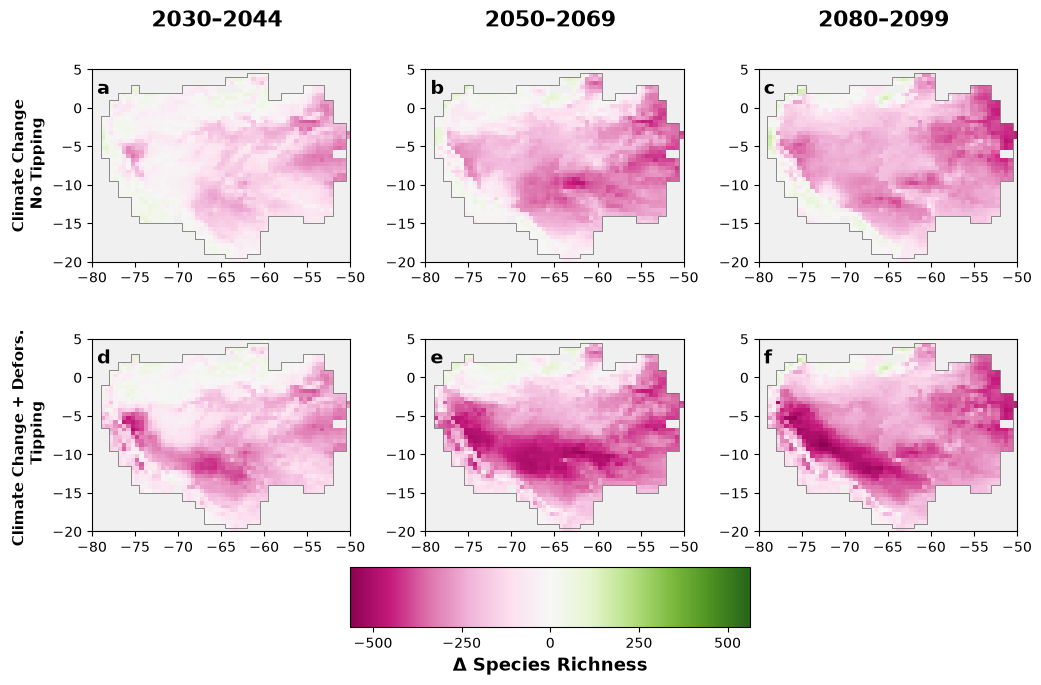

In [6]:
# Scenarios (rows)
scenario_order = [
    f"{ssp}_notip_no_deforestation",
    f"{ssp}_tip_deforestation"
]

# Time periods (columns)
time_order = ["2030_2044", "2050_2069", "2080_2099"]
col_titles = ["2030–2044", "2050–2069", "2080–2099"]

y_labels = ["Climate Change\n No Tipping", "Climate Change + Defors. \n Tipping"]

# Delta normalization
delta_norm = mcolors.TwoSlopeNorm(
    vmin=delta_min,
    vcenter=0,
    vmax=-delta_min
)

fig = plt.figure(figsize=(10, 6))
subfigs = fig.subfigures(1, 3)
subfigs[0].subplots_adjust(hspace=0.4)
axs_list = [subfigs[i].subplots(2, 1) for i in range(3)]

# Historic reference period
hist_tp = time_order[0]

for s, scen_name in enumerate(scenario_order):

    # y-axis label
    part_1, part_2 = scen_name.replace(f"{ssp}_", "").split("_", 1)
    y_label = y_labels[s]

    for i, tp in enumerate(time_order):
        subfigs[i].suptitle(col_titles[i], fontsize=16, fontweight="bold")

        delta_data = data[scen_name][tp]["delta"]
        hist_data  = data[scen_name][hist_tp]["historic"]

        # Optional: percentage change
        #prec_change_data = delta_data / hist_data.where(hist_data != 0)

        # Plot delta SR (all species)
        im = delta_data.plot.imshow(
            ax=axs_list[i][s],
            cmap="PiYG",
            norm=delta_norm,
            add_colorbar=False,
            add_labels=False
        )

        ax = axs_list[i][s]
        ax.set_facecolor("#F0F0F0")

        # Use the shared Amazon mask and trace its external pixel boundary as
        # one continuous path, matching Figures 1 and 4.
        x_values = delta_data.x.values
        y_values = delta_data.y.values
        x_grid, y_grid = np.meshgrid(x_values, y_values)
        mask_rows, mask_columns = rasterio.transform.rowcol(
            amazon_mask_transform, x_grid.ravel(), y_grid.ravel()
        )
        mask_rows = np.asarray(mask_rows).reshape(x_grid.shape)
        mask_columns = np.asarray(mask_columns).reshape(x_grid.shape)
        amazon_domain = np.zeros(x_grid.shape, dtype=bool)
        inside_mask_raster = (
            (mask_rows >= 0) & (mask_rows < amazon_mask_values.shape[0])
            & (mask_columns >= 0) & (mask_columns < amazon_mask_values.shape[1])
        )
        amazon_domain[inside_mask_raster] = np.isfinite(
            amazon_mask_values[
                mask_rows[inside_mask_raster], mask_columns[inside_mask_raster]
            ]
        )

        from scipy.ndimage import binary_closing, binary_fill_holes
        outer_amazon = binary_fill_holes(
            binary_closing(
                amazon_domain & np.isfinite(delta_data.values),
                structure=np.ones((3, 3)),
            )
        )

        from shapely.geometry import shape

        grid_transform = rasterio.Affine(
            np.diff(x_values).mean(), 0,
            x_values[0] - np.diff(x_values).mean() / 2,
            0, np.diff(y_values).mean(),
            y_values[0] - np.diff(y_values).mean() / 2,
        )
        mask_polygons = [
            shape(geometry)
            for geometry, value in rasterio.features.shapes(
                outer_amazon.astype(np.uint8),
                mask=outer_amazon,
                transform=grid_transform,
            )
            if value == 1
        ]
        amazon_outline = max(mask_polygons, key=lambda polygon: polygon.area)
        outline_x, outline_y = amazon_outline.exterior.xy
        ax.plot(
            outline_x, outline_y,
            color="#6B6B6B",
            linewidth=0.55,
            solid_capstyle="butt",
            solid_joinstyle="miter",
            zorder=10,
        )

        ax.set_title("")
        axs_list[i][s].set_xlabel("")

        if i == 0:
            axs_list[i][s].set_ylabel(y_label, fontsize=11, fontweight="bold")
        else:
            axs_list[i][s].set_ylabel("")

# Colorbar
cbar_ax = fig.add_axes([0.3, -0.05, 0.4, 0.1])
cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")

cbar.set_label("Δ Species Richness", fontsize=13, fontweight="bold")
cbar.set_ticks([-500, -250,  0, 250, 500])

import string
panel_letters = list(string.ascii_lowercase[:6])

letter_idx = 0

for row in range(2):          
    for col in range(3):      
        ax = axs_list[col][row]
        ax.text(
            0.02, 0.95,
            panel_letters[letter_idx],
            transform=ax.transAxes,
            fontsize=14,
            fontweight="bold",
            va="top",
            ha="left"
        )
        letter_idx += 1


plt.savefig(
    os.path.join(plot_dir, f"final_figure_2.png"),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()
